<a href="https://colab.research.google.com/github/kamini123576/Sustomer_Segmentation_K-Means/blob/main/K_Means_Clustering_UK_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer Segmentation Project Using K-Means

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.cluster import  KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

**Data Collection And Analysis**

In [4]:
# Loading the Dataset
data = pd.read_csv('/content/drive/MyDrive/Collab_Notebooks/Mall_Customers.csv')

1. First 5 Rows of the Dataset

In [5]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


2. Finding the number of Rows and Columns in the Dataset

In [6]:
data.shape

(200, 5)

3. Getting some information about the Dataset

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


4. Checking for the missing values in the Dataset

In [8]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


5. Choosing the annual income column and the spemding score column

In [9]:
x = data.iloc[:,[3,4]].values

In [10]:
print(x)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

6. Choosing the number of Clusters



WCSS - Within Cluster sum of squares.

In [11]:
# Finding the WCSS value for different number of clusters
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state= 42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)


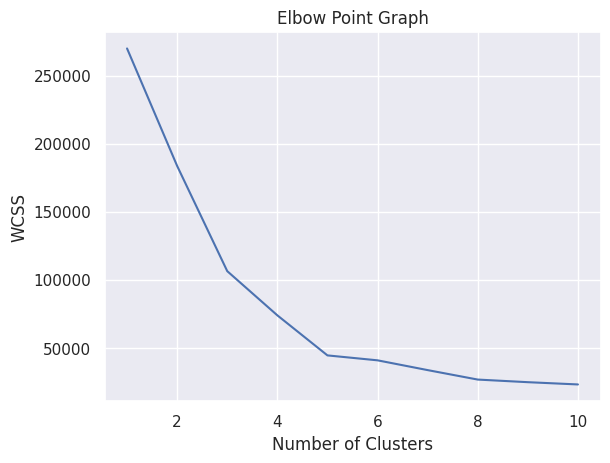

In [12]:
# Plot an Elbow Graph
sns.set()
plt.plot(range(1,11),wcss)
plt.title("Elbow Point Graph")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

7. Optimum Number of Clusters = 5
 Training the kmeans clustering Model

In [13]:
kmeans = KMeans(n_clusters=5,init = 'k-means++',random_state =0)

# Return a label for each datapoint based on their cluster

y =kmeans.fit_predict(x)
print(y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


8. Visualising all the Clusters

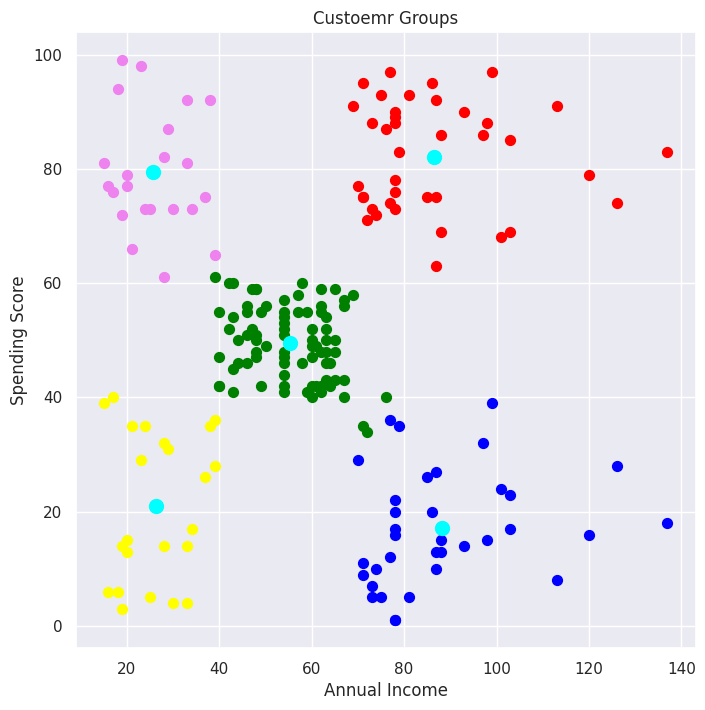

In [14]:
# Plotting all the Clusters and their centroids

plt.figure(figsize = (8,8))
plt.scatter(x[y==0,0], x[y ==0,1], s = 50, c='green',label ='Cluster1')
plt.scatter(x[y==1,0], x[y ==1,1], s = 50, c='red',label ='Cluster2')
plt.scatter(x[y==2,0], x[y ==2,1], s = 50, c='blue',label ='Cluster3')
plt.scatter(x[y==3,0], x[y ==3,1], s = 50, c='yellow',label ='Cluster4')
plt.scatter(x[y==4,0], x[y ==4,1], s = 50, c='violet',label ='Cluster5')

# plot the Centroids

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s =100,c='cyan',label ='Centroids')
plt.title("Custoemr Groups")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()